<a href="https://colab.research.google.com/github/IrfanKpm/ai-with-huggingface/blob/main/ch04_video_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import diffusers
import transformers
import cv2

## Generating Video with Diffusion

In [2]:
from diffusers import StableVideoDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = torch.device("cuda")
device

device(type='cuda')

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [5]:
model_id = "stabilityai/stable-video-diffusion-img2vid-xt"

pipe = StableVideoDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
)

pipe = pipe.to(device)

model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

In [6]:
pipe

StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

In [7]:
path = "/content/elmo.jpg"

In [8]:
from diffusers.utils import load_image,export_to_video

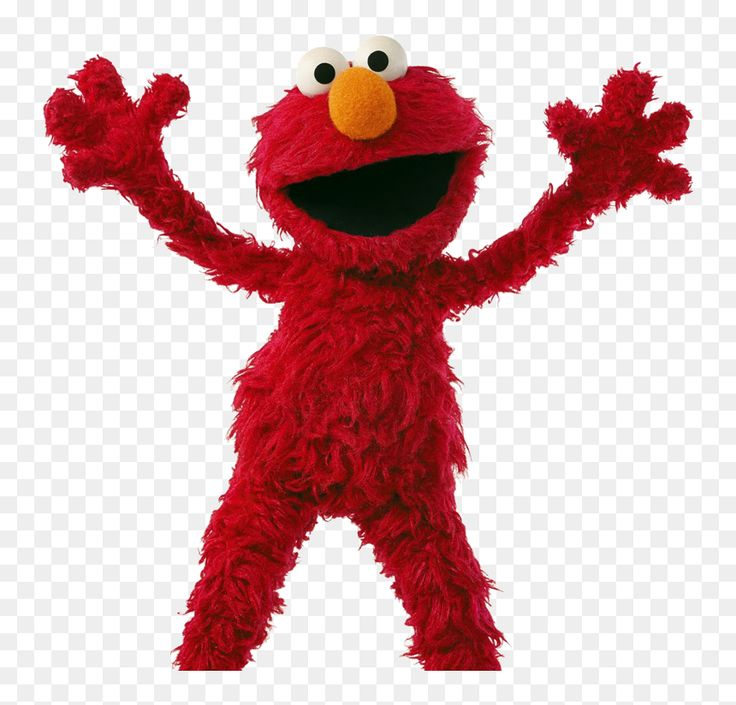

In [9]:
image = load_image(path)

image

In [10]:
pipe.enable_model_cpu_offload()

In [11]:
gen = torch.manual_seed(42)

In [12]:
frames = pipe(image,decode_chunk_size=8,generator=gen).frames[0]

  0%|          | 0/25 [00:00<?, ?it/s]

In [17]:
frames

[<PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image im

In [18]:
len(frames)

25

In [19]:
export_to_video(frames,"elmo.mp4",fps=7)

'elmo.mp4'